# Animasjon

Lat oss fyrst importera og diskutera dei biblioteka som trengst.


In [1]:
from matplotlib import pyplot as plt
from matplotlib import animation
import numpy as np
%matplotlib notebook

Det fyrste biblioteket, ``pyplot``, har me sett før. I tillegg importerer me systerbiblioteket ``animation``.
Det siste biblioteket ``numpy`` gjev tilgang til ei rekkje matematiske funksjonar, m.a. dei trigonomtriske.
Den siste lina er spesiell for bruken i Jupyter, og let oss sjå animeringa i Jupyter.

Det fyrste me gjer er å setja opp eit tomt plott.
Me lagar ein figur ``fig1``, eit aksesystem ``ax1`` i figuren, og ei «tom» line ``line``. Som me ser har lina ingen $x$- eller $y$-verdiar, båe listene ``[]`` er tomme.

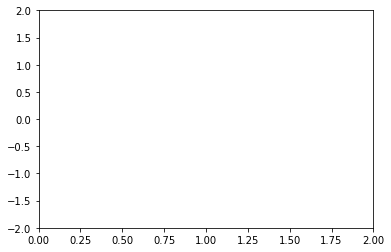

In [2]:
fig1 = plt.figure()
ax1 = plt.axes(xlim=(0, 2), ylim=(-2, 2))
line, = ax1.plot([], [], lw=2)

No treng me ein funksjon som kan setja punktene på lina.
Me skal bruka han i animeringa so me kallar han ``animate``.

In [3]:

def animate(i):
    x = np.linspace(0, 2, 1000)
    y = np.sin(2 * np.pi * (x - 0.01 * i))
    line.set_data(x, y)
    return line,

Her set me $x$-verdiane til ein vektor med 1000 verdiar i intervallet $[0,2]$,
og $y$-verdiane er sinus av $x$ med litt skalering.
Parameteren $i$ som funksjonen får inn er ei faseforskyving.
Legg merke til at ``np.sin`` reknar ut sinus for kvar verdi i vektoren som han får inn. 
Ei line reknar altso ut alle sinus-verdiane som me treng.

Den siste lina før ``return`` endrar datasettet som er brukt i plottet over.

Lat oss testa kva som skjer:

In [4]:
animate(0)

(<matplotlib.lines.Line2D at 0x7f2a6d4e5390>,)

Til animeringa treng me òg ein initialiseringsfunksjon.
Denne skal berre tømma lina:

In [5]:
def init():
    line.set_data([], [])
    return line,

Lat oss testa:

In [6]:
init()

(<matplotlib.lines.Line2D at 0x7f2a6d4e5390>,)

No er me klare til å animera.
Animeringsfunksjonen treng figuren me animerer i, funksjonen for å rekna ut nye punkt og initialiseringsfunksjonen.

In [7]:
anim = animation.FuncAnimation(fig1, animate, init_func=init,
                               frames=200, interval=20, blit=True)

Her vert 200 bilete animert med 20ms mellomrom. 
Argumentet $i$ til ``animate`` er rammenummeret i animasjonen, slik at kvar ramme har ulik faseforskyving.
Den siste parameteren ``blit=True`` gjer at python berre reknar ut dei delane av plottet som er endra. Det sparer tid.plt.show()

Det kan sjå ut som om animasjonen hakkar litt i Jupyter. Det er truleg fordi der er mykje overhead ved å køyra i vevlesaren. Dette går betre når ein køyrer python rett på jernet.

Det er òg mogleg å lagra animasjonen som ein videofil:

In [8]:
anim.save('basic_animation.mp4', fps=30, extra_args=['-vcodec', 'libx264'])

Dersom du skal køyra dømet utanom Jupyter, skal du vita at python ikkje syner plottet automatisk.
Du må gje eksplisitt beskjed om å gjera det, slik:

In [9]:
plt.show()

I Jupyter har denne lina inkje å seia.